In [87]:
## Load Data
import sys
sys.path.append("../utilities")
import utilities as u
graph = u.read_json_file("graph_filtred_gpt_20.json")
relations = u.read_json_file("graph_filtred_gpt_20.json")

In [24]:
core_concepts = ['data structure',
                         'cryptography',
                         'software engineering',
                         'computer graphic',
                         'network security',
                         'computer programming',
                         'operating system',
                         'distributed computing',
                         'machine learning'
                        ]

cc_triplets = {k : [] for k in core_concepts}
for triplet in graph:
    if triplet["subject"] in core_concepts:
        cc_triplets[triplet["subject"]].append((triplet["subject"], triplet["predicate"], triplet["object"]))
    if triplet["object"] in core_concepts:
        cc_triplets[triplet["object"]].append((triplet["subject"], triplet["predicate"], triplet["object"]))
      


In [28]:
output_file = "core_concepts_triplets.txt"

with open(output_file, "w") as file:
    for key, triplets in cc_triplets.items():
        file.write(f"********************* {key} ***********************\n")
        for triplet in triplets:
            file.write(f"{triplet}\n")
        file.write("\n")  

In [54]:
triplets = [(triplet['subject'], triplet['predicate'],triplet['object']  ) for triplet in graph]

In [55]:
len(set(triplets))

65288

In [72]:
# Calculate in-degree, out-degree, and total degree for each node
in_degrees = dict(multi_graph.in_degree())
out_degrees = dict(multi_graph.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in multi_graph.nodes()}

# Calculate average in-degree, out-degree, and total degree
average_in_degree = sum(in_degrees.values()) / len(in_degrees)
average_out_degree = sum(out_degrees.values()) / len(out_degrees)
average_total_degree = sum(total_degrees.values()) / len(total_degrees)

# Results
average_in_degree, average_out_degree, average_total_degree, in_degrees, out_degrees, total_degrees


(1.2449467630814781,
 1.2449467630814781,
 2.4898935261629562,
 {'shape reconstruction': 1,
  'application': 291,
  'damage potential scoring algorithm design': 0,
  'framework presentation': 1,
  'vaccine': 0,
  'pharmaceutical product': 1,
  'FPLA': 0,
  'programmable logic': 2,
  'CPLD': 0,
  'Pregel': 0,
  'graph processing system': 2,
  'Apache Giraph': 0,
  'facial age estimation': 0,
  'computer vision problem': 3,
  'flexible manufacturing system': 0,
  'livelock': 0,
  'anomaly': 7,
  'deadlock': 0,
  'Scratch': 0,
  'Fairfield University class module': 5,
  'AppInventor': 0,
  'Circuit Design': 0,
  'Arduino': 0,
  'final team project': 0,
  'lamp': 0,
  'electronic device': 6,
  'central light': 0,
  'air conditioner': 0,
  'door lock': 0,
  'occlusion': 10,
  'challenge': 5,
  'target scale variation': 0,
  'traditional multicore personal computer': 0,
  'computing architecture': 5,
  'surgery': 4,
  'treatment modality': 2,
  'radiation therapy': 0,
  'robot design': 0,
  

In [76]:
from collections import Counter
for k,v in in_degrees.items():
    if v > 100:
        print(k, v)



application 291
performance 237
number 150
method 406
field 103
factor 101
algorithm 345
problem 307
technique 247
tool 173
feature 164
function 134
system 374
technology 117
user 110
data 345
image 175
information 197
model 425
process 223
solution 188
framework 161
strategy 109
task 128
scheme 133
analysis 193
approach 274
result 172
one 233
network 130
structure 113
mechanism 105
operation 105
development 105


In [79]:
occ_degrees_sorted = dict(sorted(Counter(in_degrees.values()).items()))

occ_degrees_sorted

{0: 16681,
 1: 31269,
 2: 2472,
 3: 712,
 4: 347,
 5: 212,
 6: 130,
 7: 112,
 8: 78,
 9: 66,
 10: 61,
 11: 37,
 12: 31,
 13: 35,
 14: 27,
 15: 26,
 16: 18,
 17: 19,
 18: 14,
 19: 26,
 20: 19,
 21: 24,
 22: 8,
 23: 11,
 24: 6,
 25: 6,
 26: 11,
 27: 10,
 28: 9,
 29: 15,
 30: 6,
 31: 9,
 32: 6,
 33: 7,
 34: 4,
 35: 5,
 36: 7,
 37: 6,
 38: 5,
 39: 3,
 40: 3,
 41: 7,
 42: 3,
 43: 2,
 44: 2,
 45: 7,
 46: 3,
 47: 3,
 48: 1,
 49: 5,
 50: 3,
 51: 2,
 52: 4,
 53: 1,
 54: 5,
 56: 3,
 57: 1,
 58: 1,
 60: 1,
 61: 4,
 64: 3,
 65: 2,
 66: 2,
 70: 2,
 71: 2,
 72: 1,
 73: 5,
 75: 3,
 76: 2,
 78: 1,
 80: 1,
 81: 1,
 83: 2,
 84: 3,
 87: 4,
 88: 1,
 89: 1,
 90: 2,
 91: 1,
 94: 1,
 95: 1,
 97: 1,
 98: 1,
 99: 1,
 101: 1,
 103: 1,
 105: 3,
 109: 1,
 110: 1,
 113: 1,
 117: 1,
 128: 1,
 130: 1,
 133: 1,
 134: 1,
 150: 1,
 161: 1,
 164: 1,
 172: 1,
 173: 1,
 175: 1,
 188: 1,
 193: 1,
 197: 1,
 223: 1,
 233: 1,
 237: 1,
 247: 1,
 274: 1,
 291: 1,
 307: 1,
 345: 2,
 374: 1,
 406: 1,
 425: 1}

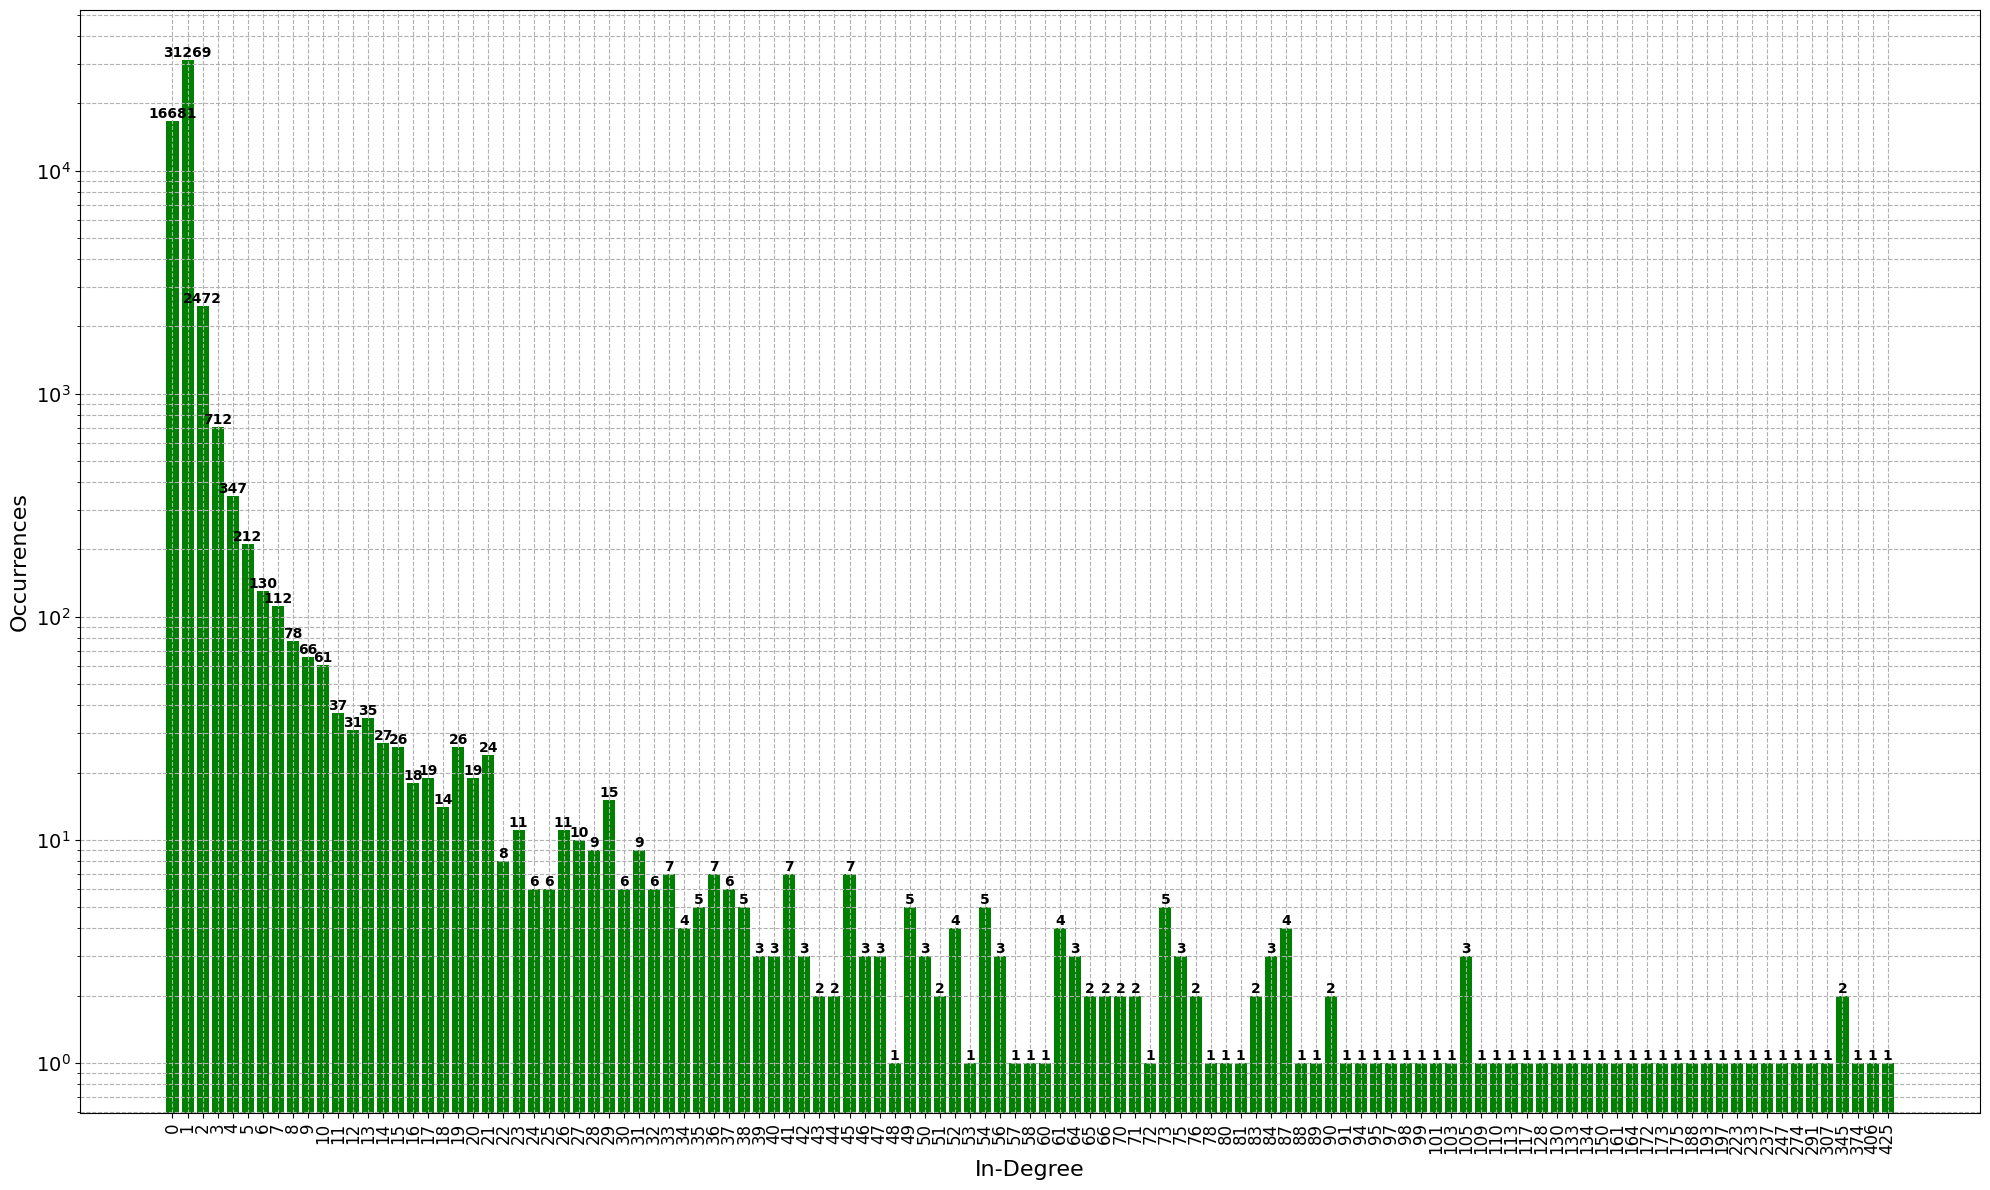

In [86]:
# Extract keys and values from the large in-degree Counter dictionary
keys = list(occ_degrees_sorted.keys())
values = list(occ_degrees_sorted.values())

# Increase the figure size to make all x-axis labels clear
plt.figure(figsize=(20, 12))

# Plot the bar chart
plt.bar(sorted_keys_str, sorted_values, color=colors, width=0.8)
plt.yscale('log')
plt.xlabel('In-Degree', fontsize=16)
plt.ylabel('Occurrences', fontsize=16)
plt.grid(True, which="both", ls="--")

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=14)

# Add values above the bars
for i in range(len(sorted_keys_str)):
    plt.text(sorted_keys_str[i], sorted_values[i], str(sorted_values[i]), ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()




In [40]:
# Création du graphe
graph = nx.DiGraph()
for relation in relations:
    graph.add_edge(relation['subject'], relation['object'], predicate=relation['predicate'])

# Calcul du degré moyen
average_degree = sum(dict(graph.degree()).values()) / graph.number_of_nodes()

# Affichage du résultat
print(f"Degré moyen par nœud : {average_degree:.2f}")

Degré moyen par nœud : 2.47


### Edges dropping test

In [93]:
import torch
config = {
    "device": "cuda" if torch.cuda.is_available() else "cpu", #
    "out_channels": [500,250],
    "num_layers": 2,
    "num_bases": 10,
    "alpha": 0.01,
    "max_masking_percentage": 0.3,
    "total_drop_rate": 0.2,
    "learning_rate": 0.001,
    "batch_size": 256,
    "cosine_loss_weight": 0.5,
    "shuffle": False,
    "num_neighbors": [100, 50],
    "num_epochs": 150,
    "Entities_path": "../outputs/EntitiesBertEmbeddingAugmented.pickle",
    "Edges_path": "../outputs/PredicatesBertEmbeddingAugmented.pickle",
    "KG_path": "../../data/graph_filtred_gpt_20.json",
    "Gs_path": "../../data/gs_vf.xlsx",
    "Gs_path_no_other": "../../data/gs_vf_no_other.xlsx",
    "core_concepts" : [  'data structure',
                         'cryptography',
                         'software engineering',
                         'computer graphic',
                         'network security',
                         'computer programming',
                         'operating system',
                         'distributed computing',
                         'machine learning'
                        ],
    "options": ["X"]
}




In [94]:
import sys


from GraphDataPreparation import GraphDataPreparation



sys.path.append("../utilities")
import utilities as u

import torch
import random
import numpy as np
import os

KG_path = config["KG_path"]
gdp = GraphDataPreparation("../src/outputs/EntitiesBertEmbeddingAugmented.pickle", "graph_filtred_gpt_20.json",
                               edges_embd_path="../src/outputs/PredicatesBertEmbeddingAugmented.pickle", is_directed=True)
data = gdp.prepare_graph_with_type().to(config["device"])
print(data)

Building NetworkX graph with unique relation type IDs
----------- Unique relation -------> 110
Building PyTorch Geometric Data object with unique relation type IDs
Data(x=[52689, 768], edge_index=[2, 65155], edge_attr=[65155, 768], edge_type=[65155])


In [109]:
def relation_based_edge_dropping_balanced(data, total_drop_rate, max_drop_fraction_per_node=0.3, random_seed=42):

    """
    Suppression équilibrée des relations dans un graphe en limitant les suppressions par nœud
    tout en évitant l'isolation des nœuds.

    :param data: Objet Data contenant le graphe.
    :param total_drop_rate: Fraction globale d'arêtes à supprimer.
    :param max_drop_fraction_per_node: Fraction maximale d'arêtes pouvant être supprimées par nœud.
    :return: Nouvel objet Data avec les arêtes mises à jour, indices supprimés, et types supprimés.
    """
    # Créer des copies pour éviter de modifier l'objet data original
    device = data.x.device
    torch.manual_seed(random_seed)
    if device == "cuda":
        torch.cuda.manual_seed_all(random_seed)

    assert 0 <= total_drop_rate <= 1, "total_drop_rate doit être entre 0 et 1"
    assert 0 <= max_drop_fraction_per_node <= 1, "max_drop_fraction_per_node doit être entre 0 et 1"

    edge_index = data.edge_index.clone()
    edge_type = data.edge_type.clone()

    # Calcul de la fréquence de chaque type de relation
    edge_types, edge_counts = torch.unique(edge_type, return_counts=True)
    total_edges = edge_index.size(1)

    # Calcul du nombre total d'arêtes à supprimer
    num_edges_to_drop = int(total_edges * total_drop_rate)

    # Calcul du nombre d'arêtes à supprimer par type de relation
    edges_to_drop_per_type = {edge_type.item(): int(num_edges_to_drop * (count.item() / total_edges))
                              for edge_type, count in zip(edge_types, edge_counts)}

    # Suivi des arêtes à garder
    keep_edge_indices = list(range(total_edges))
    removed_edge_indices = []  # Indices des arêtes supprimées

    # Pour chaque type de relation, supprimer les arêtes de manière équilibrée
    for edge_type_value, edges_to_drop in edges_to_drop_per_type.items():
        # Trouver les indices des arêtes de ce type
        edge_indices_of_type = torch.where(edge_type == edge_type_value)[0].tolist()

        # Indices à supprimer
        indices_to_remove = []

        while len(indices_to_remove) < edges_to_drop and edge_indices_of_type:
            candidate = edge_indices_of_type.pop(torch.randint(0, len(edge_indices_of_type), (1,)).item())

            # Vérifier la contrainte de suppression par nœud
            src, dst = edge_index[:, candidate]
            remaining_edges_src = len(torch.where(edge_index[0] == src)[0]) + len(
                torch.where(edge_index[1] == src)[0])
            remaining_edges_dst = len(torch.where(edge_index[0] == dst)[0]) + len(
                torch.where(edge_index[1] == dst)[0])

            max_removable_edges_src = int(remaining_edges_src * max_drop_fraction_per_node)
            max_removable_edges_dst = int(remaining_edges_dst * max_drop_fraction_per_node)

            # Vérifier également la condition de non-isolation des nœuds
            if (remaining_edges_src > max_removable_edges_src and
                    remaining_edges_dst > max_removable_edges_dst and
                    remaining_edges_src > 1 and
                    remaining_edges_dst > 1):
                indices_to_remove.append(candidate)

        # Mettre à jour les listes des arêtes gardées et supprimées
        removed_edge_indices.extend(indices_to_remove)
        keep_edge_indices = [idx for idx in keep_edge_indices if idx not in indices_to_remove]

    # Récupérer les types des arêtes supprimées
    removed_edge_types = edge_type[removed_edge_indices]

    # Création d'un nouvel objet Data avec les arêtes mises à jour
    new_data = Data(
        x=data.x,  # Copie des nœuds
        edge_index=edge_index[:, keep_edge_indices],  # Arêtes mises à jour
        edge_type=edge_type[keep_edge_indices],  # Types d'arêtes mis à jour
    )

    return new_data, torch.tensor(removed_edge_indices), removed_edge_types


In [110]:
data_dropped, removed_edge_indices, types = relation_based_edge_dropping_balanced(data, 0.2, max_drop_fraction_per_node=0.3)

In [159]:
removed_edge_indices[20]

tensor(11138)

In [124]:
removed_edge_indices.shape[0] + data_dropped.edge_index.shape[1]

65155

In [150]:
data.edge_index[0][29275]

tensor(17270, device='cuda:0')

In [151]:
int(data.edge_index[1][29275])

17271

In [153]:
for i,j in zip(data.edge_index[0], data.edge_index[1]):
    if int(i) == 17270 and  int(j) == 17271:
            print("oket")

oket


In [157]:
types[20]

tensor(1, device='cuda:0')

In [162]:
data.edge_type[11138]

tensor(1, device='cuda:0')

In [127]:
removed_edge_indices

tensor([10497,  3575, 34128,  ..., 10103, 10884, 29275])

In [99]:
id_predicates = {v:k for k,v in gdp.predicate_to_id.items()}

# Avant suppression
print("Avant suppression:")
print(f"Nombre total de nœuds : {data.x.size(0)}")
print(f"Nombre total d'arêtes : {data.edge_index.size(1)}")

# Suppression des liens

# Après suppression
print("\nAprès suppression:")
print(f"Nombre total de nœuds : {data_dropped.x.size(0)}")
print(f"Nombre total d'arêtes : {data_dropped.edge_index.size(1)}")

# Distribution comparative
def print_edge_type_distribution(data, title, id_predicates):
    unique_edge_types, edge_type_counts = torch.unique(data.edge_type, return_counts=True)
    print(f"\n{title}")
    for edge_type, count in zip(unique_edge_types, edge_type_counts):
        print(f" {id_predicates[edge_type.item()]}: {count.item()} arêtes")

print_edge_type_distribution(data, "Distribution avant suppression", id_predicates)
print_edge_type_distribution(data_dropped, "Distribution après suppression", id_predicates)

Avant suppression:
Nombre total de nœuds : 52689
Nombre total d'arêtes : 65155

Après suppression:
Nombre total de nœuds : 52689
Nombre total d'arêtes : 52168

Distribution avant suppression
 accelerate: 23 arêtes
 acquire: 834 arêtes
 adapt: 162 arêtes
 affect: 354 arêtes
 aim: 68 arêtes
 analyze: 827 arêtes
 arise: 25 arêtes
 associate: 88 arêtes
 avoid: 33 arêtes
 base: 1324 arêtes
 become: 66 arêtes
 bring: 40 arêtes
 call: 152 arêtes
 cause: 147 arêtes
 challenge: 35 arêtes
 change: 36 arêtes
 characterize: 55 arêtes
 choose: 31 arêtes
 classifie: 62 arêtes
 combine: 149 arêtes
 come: 28 arêtes
 compare: 129 arêtes
 confirm: 46 arêtes
 consume: 34 arêtes
 contribute: 233 arêtes
 convert: 22 arêtes
 correlate: 20 arêtes
 define: 103 arêtes
 demonstrate: 209 arêtes
 depend: 79 arêtes
 describe: 126 arêtes
 discuss: 43 arêtes
 display: 27 arêtes
 distinguish: 21 arêtes
 divide: 29 arêtes
 eliminate: 22 arêtes
 ensure: 37 arêtes
 execute: 695 arêtes
 exist: 40 arêtes
 explore: 50 arêt

In [100]:
id_predicates = {v:k for k,v in gdp.predicate_to_id.items()}


C:\Users\admin-user\AppData\Local\Temp\ipykernel_50416\1552625825.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=90, fontsize=10)
C:\Users\admin-user\AppData\Local\Temp\ipykernel_50416\1552625825.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=90, fontsize=10)


<Figure size 2000x2000 with 0 Axes>

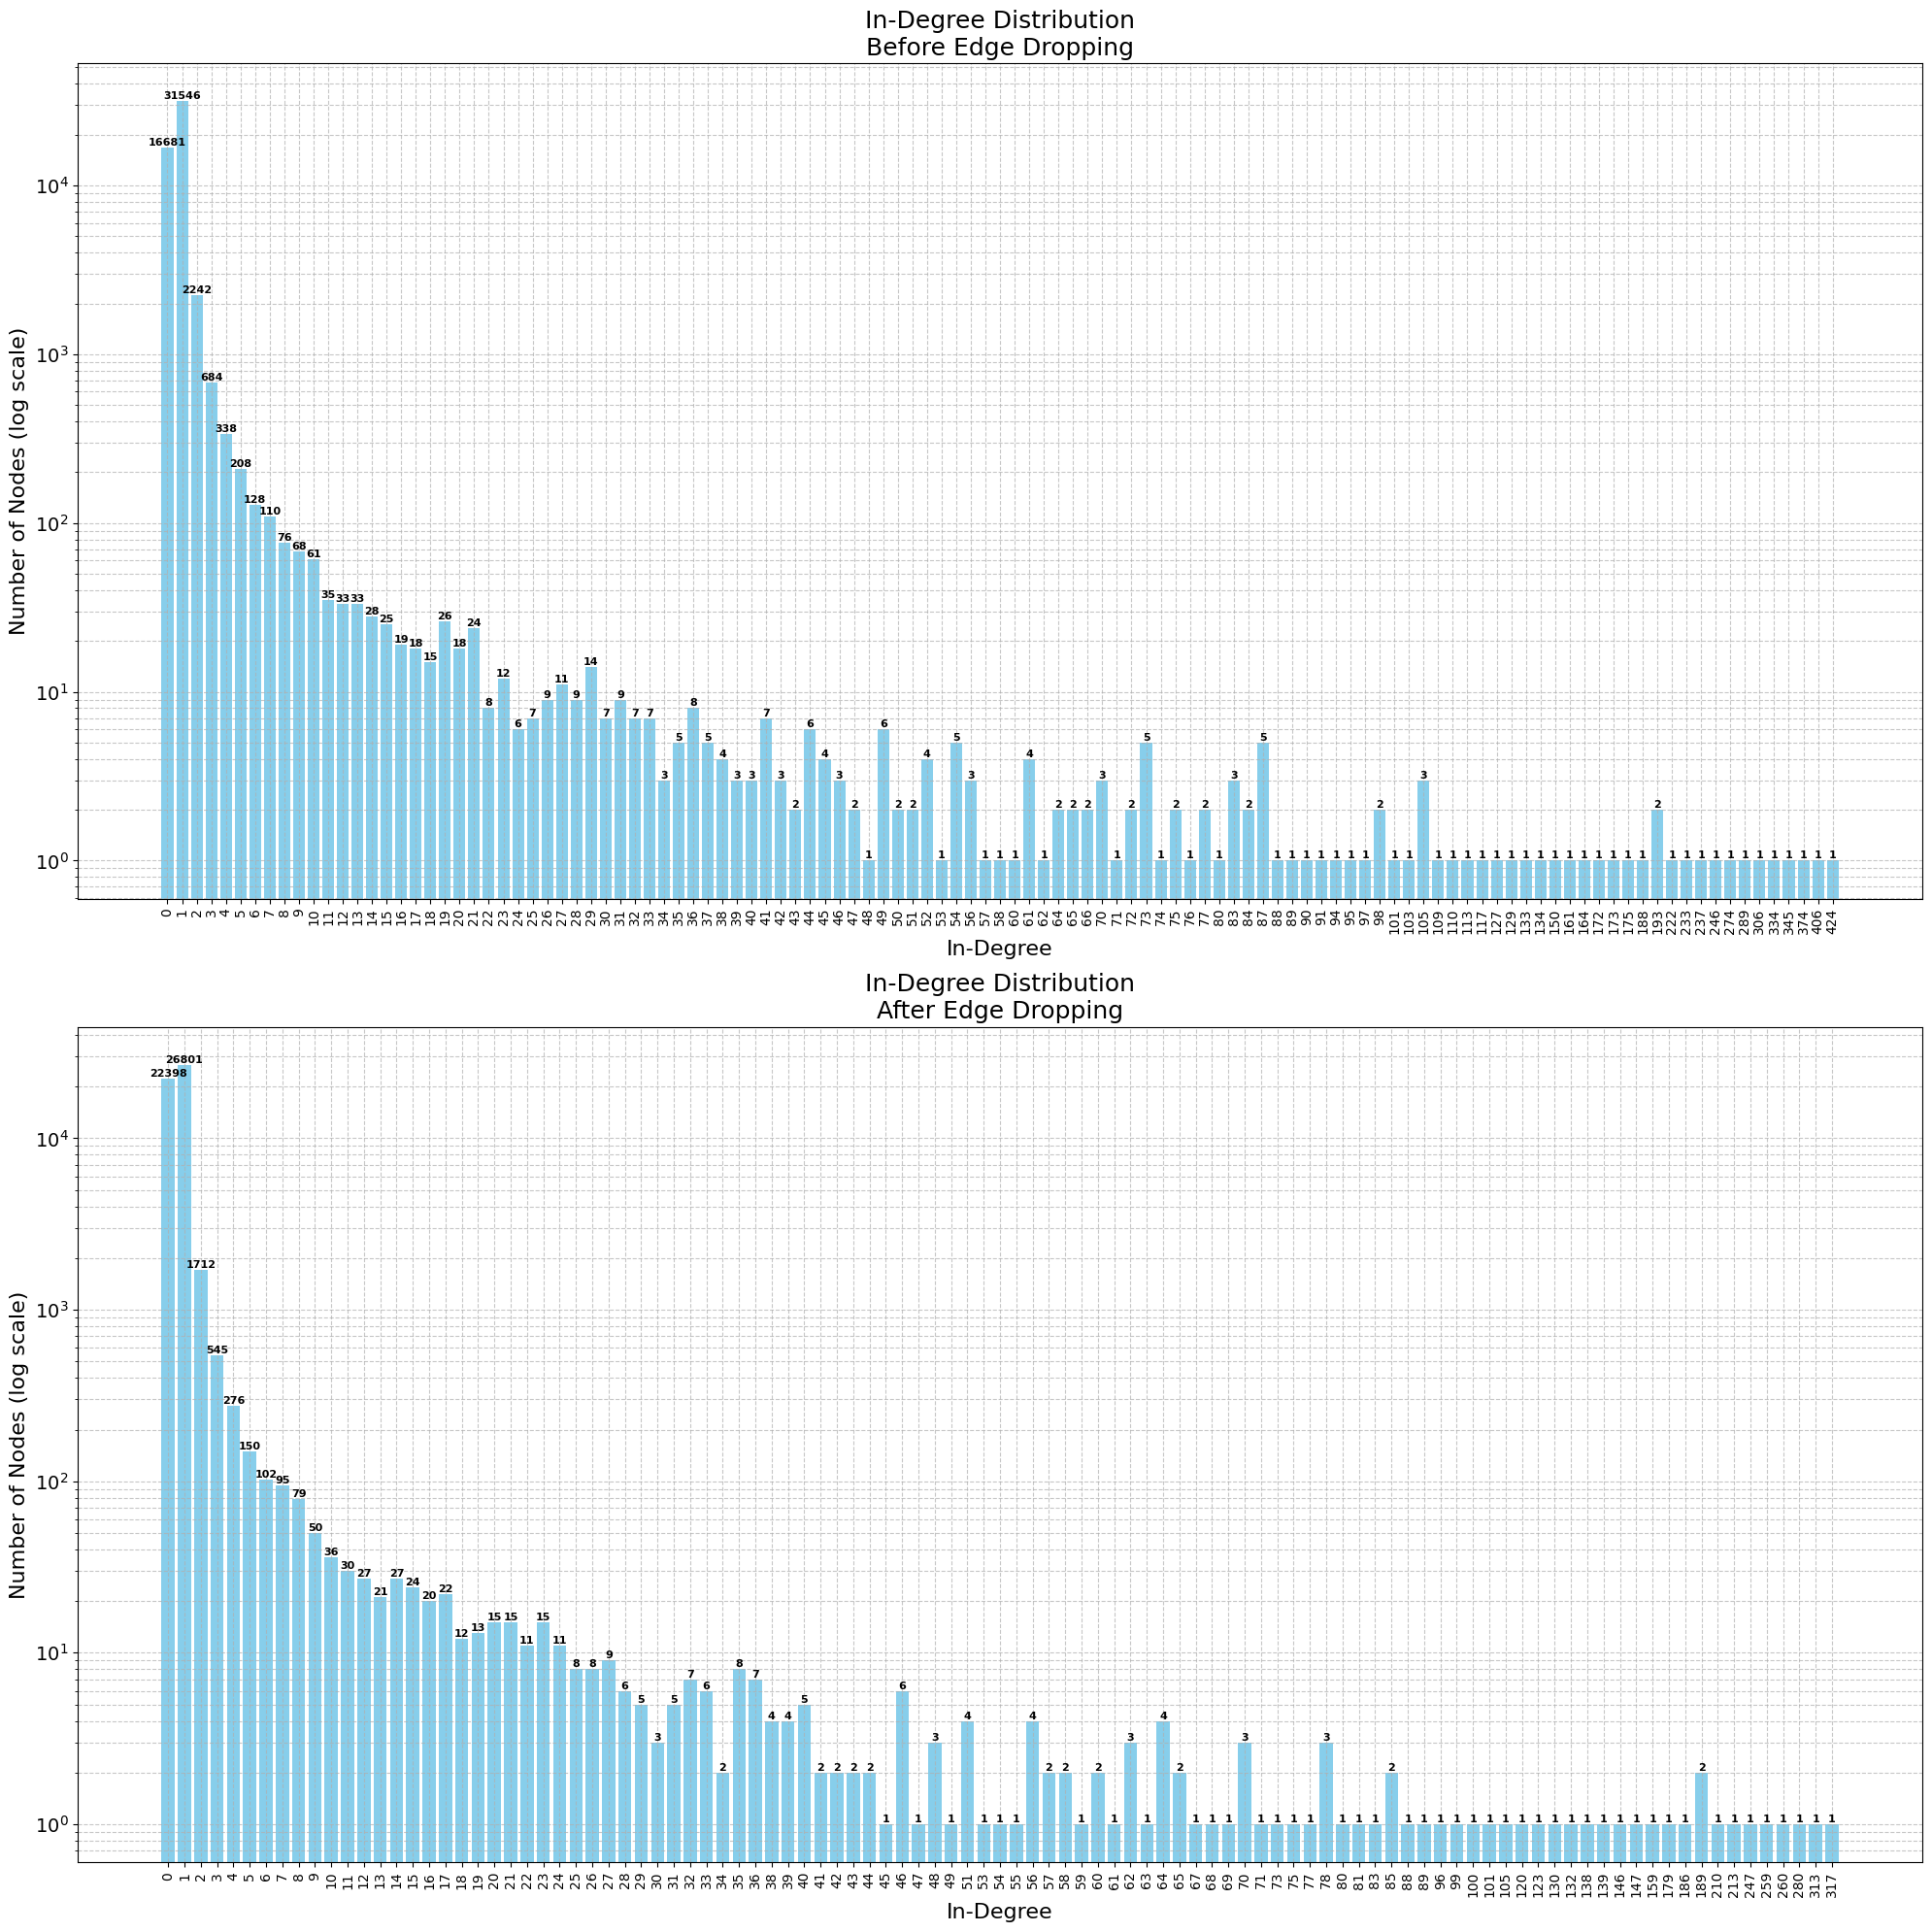

Statistiques des degrés entrants avant suppression:
Degré entrant moyen : 1.24
Degré entrant médian : 1
Degré entrant max : 424
Degré entrant min : 0

Statistiques des degrés entrants après suppression:
Degré entrant moyen : 0.99
Degré entrant médian : 1
Degré entrant max : 317
Degré entrant min : 0


In [108]:
import torch
import matplotlib.pyplot as plt
from collections import Counter

def compute_in_degrees(edge_index, num_nodes):
    # Calcul des degrés entrants
    in_degrees = torch.zeros(num_nodes, dtype=torch.long)
    
    # Compter les degrés entrants
    for dst in edge_index[1]:
        in_degrees[dst] += 1
    
    return in_degrees

# Calcul des degrés entrants avant suppression
in_degrees_before = compute_in_degrees(data.edge_index, data.x.size(0))

# Suppression des liens
data_dropped = relation_based_edge_dropping_balanced(data, total_drop_rate=0.2)

# Calcul des degrés entrants après suppression
in_degrees_after = compute_in_degrees(data_dropped.edge_index, data_dropped.x.size(0))

# Fonction pour créer le plot
def plot_in_degree_distribution(ax, in_degrees, title):
    # Créer un compteur des degrés
    degree_counter = Counter(in_degrees.numpy())
    
    # Trier les degrés
    sorted_degrees = sorted(degree_counter.items(), key=lambda x: x[0])
    
    # Séparer les clés et valeurs
    keys = [str(x[0]) for x in sorted_degrees]
    values = [x[1] for x in sorted_degrees]
    
    # Plot du bar chart
    ax.bar(keys, values, color='skyblue', width=0.8)
    
    # Échelle logarithmique pour l'axe y
    ax.set_yscale('log')
    
    # Étiquettes et titres
    ax.set_title(title, fontsize=18)
    ax.set_xlabel('In-Degree', fontsize=16)
    ax.set_ylabel('Number of Nodes (log scale)', fontsize=16)
    
    # Grille
    ax.grid(True, which="both", ls="--", alpha=0.7)
    
    # Rotation des étiquettes x
    ax.set_xticklabels(keys, rotation=90, fontsize=10)
    ax.tick_params(axis='y', labelsize=14)
    
    # Ajouter les valeurs au-dessus des barres
    for i, v in enumerate(values):
        ax.text(keys[i], v, str(v), ha='center', va='bottom', fontsize=8, weight='bold')

# Créer la figure
plt.figure(figsize=(20, 20))

# Création des sous-graphiques (2 lignes, 1 colonne)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

# Distribution avant suppression
plot_in_degree_distribution(ax1, in_degrees_before, 'In-Degree Distribution\nBefore Edge Dropping')

# Distribution après suppression
plot_in_degree_distribution(ax2, in_degrees_after, 'In-Degree Distribution\nAfter Edge Dropping')

plt.tight_layout()
plt.show()

# Statistiques
print("Statistiques des degrés entrants avant suppression:")
print(f"Degré entrant moyen : {in_degrees_before.float().mean().item():.2f}")
print(f"Degré entrant médian : {in_degrees_before.median().item()}")
print(f"Degré entrant max : {in_degrees_before.max().item()}")
print(f"Degré entrant min : {in_degrees_before.min().item()}")

print("\nStatistiques des degrés entrants après suppression:")
print(f"Degré entrant moyen : {in_degrees_after.float().mean().item():.2f}")
print(f"Degré entrant médian : {in_degrees_after.median().item()}")
print(f"Degré entrant max : {in_degrees_after.max().item()}")
print(f"Degré entrant min : {in_degrees_after.min().item()}")